In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
def wrangle(path, set_col_name):
    # Load data
    df = pd.read_csv(path, skiprows=1)

    # Convert first column to datetime 
    df['date'] = pd.to_datetime(df['unix'], unit = "s")
    df = df.sort_values(by='date', ascending=True)

    # Set index
    df.set_index('date', inplace=True)

    # Only keep certain columns 
    df = df[['open', 'high', 'low', 'close']]

    # # Rename columns
    # df = df.rename(columns={'close': set_col_name})

    return df

In [3]:
df = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitstamp_BTCUSD_1h.csv",
             'BTC')
# Ether = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitstamp_ETHUSD_1h.csv",
#                 'ETH')
# XRP = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitstamp_XRPUSD_1h.csv",
#               'XRP')


In [4]:
# df = pd.merge(Bitcoin, Ether, on='date', how='outer')
# df = pd.merge(df, XRP, on='date', how='outer')

In [5]:
# Only select data before "2025-01-01" 
df = df[df.index < "2025-01-01"]
df

,open,high,low,close
date,,,,
2018-05-15 06:00:00,8733.86,8796.68,8707.28,8740.99
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90
...,...,...,...,...
2024-12-31 19:00:00,93760.00,94158.00,93600.00,94008.00
2024-12-31 20:00:00,94025.00,94059.00,93300.00,93415.00
2024-12-31 21:00:00,93386.00,93777.00,93336.00,93682.00


In [6]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 58146 entries, 2018-05-15 06:00:00 to 2024-12-31 23:00:00
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    58146 non-null  float64
 1   high    58146 non-null  float64
 2   low     58146 non-null  float64
 3   close   58146 non-null  float64
dtypes: float64(4)
memory usage: 2.2 MB
None
                open           high            low          close
count   58146.000000   58146.000000   58146.000000   58146.000000
mean    29058.953961   29185.783902   28924.437684   29060.513187
std     22296.323922   22388.672956   22198.723557   22297.945107
min      3139.760000    3158.340000    3122.280000    3139.760000
25%      9169.080000    9196.015000    9138.000000    9169.082500
50%     23867.000000   23974.260000   23761.400000   23872.000000
75%     43658.675000   43833.750000   43475.870000   43661.872500
max    108293.000000  108364.000000  107128.000000  108276.000

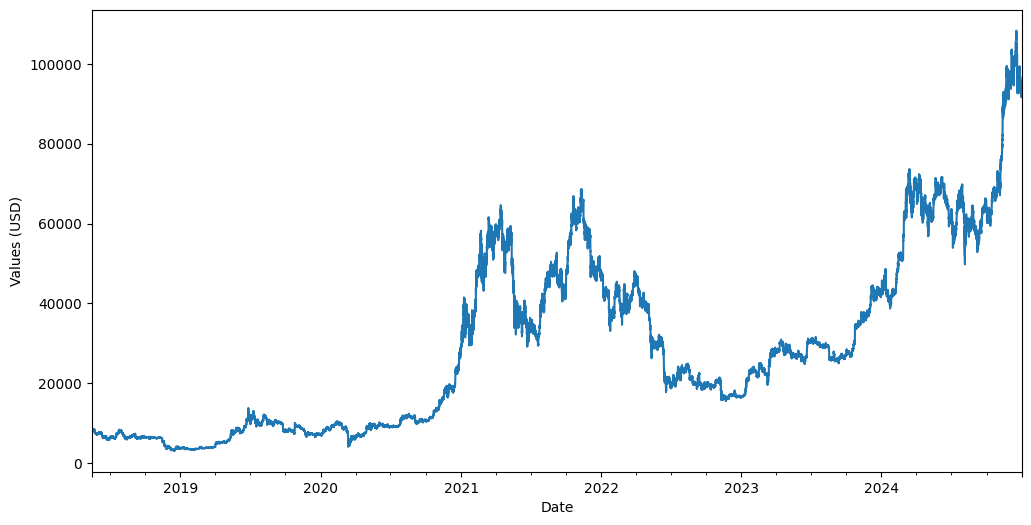

In [7]:
# Plot the 'close' prices
df['close'].plot(figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Values (USD)');

In [8]:
df.head()

,open,high,low,close
date,,,,
2018-05-15 06:00:00,8733.86,8796.68,8707.28,8740.99
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90


In [9]:
df.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv")

## Wrangle test data

In [10]:
df_test = wrangle("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitstamp_BTCUSD_1h_test.csv",
             'BTC')

In [11]:
df_test.head()

,open,high,low,close
date,,,,
2018-05-15 06:00:00,8733.86,8796.68,8707.28,8740.99
2018-05-15 07:00:00,8740.99,8766.00,8721.11,8739.00
2018-05-15 08:00:00,8739.00,8750.27,8660.53,8728.49
2018-05-15 09:00:00,8728.49,8754.40,8701.35,8708.32
2018-05-15 10:00:00,8708.32,8865.00,8695.11,8795.90


In [12]:
# Only select data after 2025 as my test set 
df_test = df_test[df_test.index >= "2025-01-01"]
df_test

,open,high,low,close
date,,,,
2025-01-01 00:00:00,93347.0,94272.0,93318.0,94211.0
2025-01-01 01:00:00,94188.0,94188.0,93416.0,93421.0
2025-01-01 02:00:00,93421.0,93893.0,93416.0,93858.0
2025-01-01 03:00:00,93823.0,93825.0,93533.0,93629.0
2025-01-01 04:00:00,93629.0,93629.0,93338.0,93355.0
...,...,...,...,...
2025-02-01 20:00:00,101663.0,101663.0,100931.0,101288.0
2025-02-01 21:00:00,101288.0,101540.0,101008.0,101207.0
2025-02-01 22:00:00,101182.0,101404.0,100498.0,100660.0


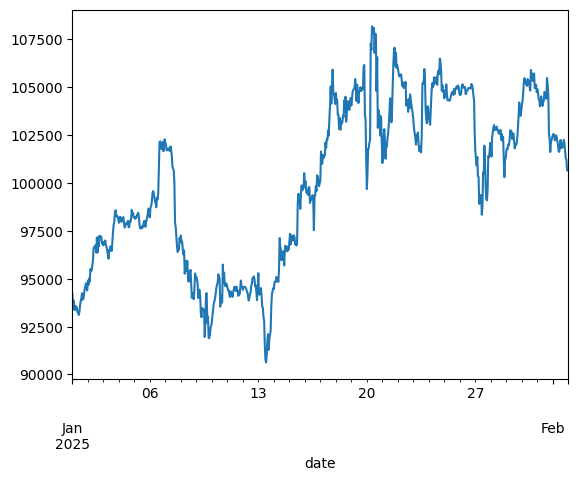

In [13]:
df_test['close'].plot();

In [14]:
df_test.to_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_test_data.csv")